
# EcoShield AI — CatBoost Ağır Model Notebook'u

Bu notebook, **IEEE-CIS Fraud Detection** veri seti üzerinde CatBoost ağır model adayını baştan sona eğitir.

Notebook kendi içinde şu işlemleri yapar:

1. Proje kökünü ve veri dosyalarını otomatik bulur.
2. `train_transaction.csv` ve `train_identity.csv` dosyalarını ilerleme göstergesiyle okur.
3. Dosyaları `TransactionID` üzerinden birleştirir.
4. Çok yüksek eksik oranlı ve sabit kolonları temizler.
5. Kategorik kolonları CatBoost'un doğal kategorik desteğine hazırlar.
6. Veriyi stratified biçimde train / validation / test olarak ayırır.
7. GPU ile CatBoost eğitmeyi dener; GPU başarısız olursa CPU'ya otomatik geçer.
8. Validation setinde threshold tuning yapar.
9. Test setinde final metrikleri hesaplar.
10. Modeli, metrikleri, tahminleri ve görselleri repo klasörlerine kaydeder.

> Notebook bağımsız çalışır. Önceden hazırlanmış bir preprocessing notebook'una ihtiyaç duymaz.
>
> İlk çalıştırmada üst menüden **Run All** kullanabilirsiniz. Sadece aşağıdaki yapılandırma hücresini kontrol etmeniz yeterlidir.



## Kullanılan proje yapısı

Notebook repo içinde `notebooks/` klasöründe çalıştırılacak şekilde hazırlanmıştır.

Beklenen temel yapı:

```text
YZTA-Bootcamp-2026/
├── data/
│   └── raw/
│       ├── train_transaction.csv
│       └── train_identity.csv
├── notebooks/
│   └── 04_catboost_heavy_model_ieee_cis.ipynb
├── models/
│   └── heavy/
└── outputs/
    ├── figures/
    ├── metrics/
    └── predictions/
```

CSV dosyaları `data/raw/` altında farklı bir alt klasördeyse notebook onları yine otomatik arar.


In [ ]:

# ============================================================
# 1) YAPILANDIRMA
# ============================================================

# Tam eğitim için False bırakın.
# Önce kodu hızlıca kontrol etmek isterseniz True yapabilirsiniz.
QUICK_MODE = False

# QUICK_MODE=True olduğunda okunacak maksimum transaction satırı.
QUICK_ROWS = 150_000

# CSV okuma sırasında her seferinde işlenecek satır sayısı.
CSV_CHUNK_SIZE = 300_000

# Çok yüksek eksik oranına sahip kolonları kaldırma sınırı.
# 0.98 = değerlerinin %98'inden fazlası eksik olan kolonları kaldır.
HIGH_MISSING_THRESHOLD = 0.98

# Veri bölme oranları.
TEST_SIZE = 0.15
VALIDATION_SIZE = 0.15

# Tekrarlanabilirlik.
RANDOM_STATE = 42

# Önce GPU denenecek. Sorun çıkarsa notebook otomatik CPU'ya geçer.
PREFERRED_DEVICE = "GPU"

# Validation threshold seçiminde hedeflenen minimum recall.
MIN_RECALL_TARGET = 0.90

# CatBoost başlangıç parametreleri.
CATBOOST_ITERATIONS = 1500
CATBOOST_DEPTH = 8
CATBOOST_LEARNING_RATE = 0.05
EARLY_STOPPING_ROUNDS = 150

print("Yapılandırma hazır.")
print("QUICK_MODE:", QUICK_MODE)
print("Tercih edilen cihaz:", PREFERRED_DEVICE)


Yapılandırma hazır.
QUICK_MODE: False
Tercih edilen cihaz: GPU



## Paketlerin kontrol edilmesi

Bu hücre gerekli kütüphanelerin kurulu olup olmadığını denetler. Eksik paket varsa kullanılan Python ortamına otomatik kurar.

Kurulumdan sonra import hatası oluşursa kernel'i bir kez yeniden başlatıp notebook'u tekrar **Run All** ile çalıştırın.


In [2]:

# ============================================================
# 2) GEREKLİ PAKETLERİ KONTROL ET / KUR
# ============================================================

import importlib.util
import subprocess
import sys

required_packages = {
    "catboost": "catboost",
    "pandas": "pandas",
    "numpy": "numpy",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "tqdm": "tqdm",
    "psutil": "psutil",
}

missing_packages = [
    pip_name
    for import_name, pip_name in required_packages.items()
    if importlib.util.find_spec(import_name) is None
]

if missing_packages:
    print("Eksik paketler kuruluyor:", missing_packages)
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", *missing_packages]
    )
    print("Kurulum tamamlandı.")
else:
    print("Gerekli paketlerin tamamı kurulu.")


Eksik paketler kuruluyor: ['catboost']
Kurulum tamamlandı.


In [3]:

# ============================================================
# 3) IMPORTLAR
# ============================================================

import gc
import json
import os
import platform
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil

from catboost import CatBoostClassifier, Pool
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)

print("Python:", sys.version.split()[0])
print("İşletim sistemi:", platform.platform())
print("CatBoost import edildi.")


Python: 3.11.15
İşletim sistemi: Windows-10-10.0.26200-SP0
CatBoost import edildi.


c:\Users\pc\anaconda3\envs\torchcuda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:

# ============================================================
# 4) PROJE KÖKÜNÜ VE ÇIKTI KLASÖRLERİNİ BUL
# ============================================================

def find_project_root(start_path: Path) -> Path:
    start_path = start_path.resolve()

    candidates = [start_path, *start_path.parents]

    for candidate in candidates:
        if (candidate / "data").exists():
            return candidate

    # Notebook /mnt/data gibi başka bir yerde açılmışsa mevcut klasörü kullan.
    return start_path


PROJECT_ROOT = find_project_root(Path.cwd())

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"

MODEL_DIR = PROJECT_ROOT / "models" / "heavy"
METRICS_DIR = PROJECT_ROOT / "outputs" / "metrics"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
PREDICTIONS_DIR = PROJECT_ROOT / "outputs" / "predictions"

for directory in [
    MODEL_DIR,
    METRICS_DIR,
    FIGURES_DIR,
    PREDICTIONS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Proje kökü:", PROJECT_ROOT)
print("Ham veri klasörü:", RAW_DIR)
print("Model çıktısı:", MODEL_DIR)
print("Metrik çıktısı:", METRICS_DIR)
print("Görsel çıktısı:", FIGURES_DIR)
print("Tahmin çıktısı:", PREDICTIONS_DIR)


Proje kökü: C:\Users\pc\Desktop\YZTA-Bootcamp-2026
Ham veri klasörü: C:\Users\pc\Desktop\YZTA-Bootcamp-2026\data\raw
Model çıktısı: C:\Users\pc\Desktop\YZTA-Bootcamp-2026\models\heavy
Metrik çıktısı: C:\Users\pc\Desktop\YZTA-Bootcamp-2026\outputs\metrics
Görsel çıktısı: C:\Users\pc\Desktop\YZTA-Bootcamp-2026\outputs\figures
Tahmin çıktısı: C:\Users\pc\Desktop\YZTA-Bootcamp-2026\outputs\predictions



## Yardımcı fonksiyonlar

Aşağıdaki fonksiyonlar:

- RAM kullanımını gösterir,
- CSV dosyalarını parçalar halinde okuyarak işlenen satır sayısını gösterir,
- sayısal veri tiplerini küçülterek RAM kullanımını azaltır,
- adımların ne kadar sürdüğünü raporlar.


In [ ]:

# ============================================================
# 5) YARDIMCI FONKSİYONLAR
# ============================================================

def memory_usage_gb() -> float:
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / (1024 ** 3)


def print_memory(note: str = "") -> None:
    prefix = f"[{note}] " if note else ""
    print(f"{prefix}RAM kullanımı: {memory_usage_gb():.2f} GB")


def downcast_numeric_dtypes(frame: pd.DataFrame) -> pd.DataFrame:
    float_cols = frame.select_dtypes(include=["float64"]).columns
    int_cols = frame.select_dtypes(include=["int64"]).columns

    for col in float_cols:
        frame[col] = pd.to_numeric(frame[col], downcast="float")

    for col in int_cols:
        frame[col] = pd.to_numeric(frame[col], downcast="integer")

    return frame


def read_csv_with_progress(
    path: Path,
    chunksize: int = 300_000,
    nrows: int | None = None,
) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Dosya bulunamadı: {path}")

    started = time.perf_counter()
    chunks = []
    processed_rows = 0

    reader = pd.read_csv(
        path,
        chunksize=chunksize,
        nrows=nrows,
        low_memory=False,
    )

    progress = tqdm(
        desc=f"{path.name} okunuyor",
        unit=" satır",
    )

    for chunk in reader:
        chunk = downcast_numeric_dtypes(chunk)
        chunks.append(chunk)

        processed_rows += len(chunk)
        progress.update(len(chunk))
        progress.set_postfix(
            ram=f"{memory_usage_gb():.2f} GB",
            refresh=False,
        )

    progress.close()

    result = pd.concat(chunks, ignore_index=True)
    elapsed = time.perf_counter() - started

    print(
        f"{path.name}: {len(result):,} satır, "
        f"{result.shape[1]} kolon, süre={elapsed:.1f} sn"
    )
    print_memory(path.name)

    del chunks
    gc.collect()

    return result


def locate_file(filename: str) -> Path:
    direct_candidates = [
        RAW_DIR / filename,
        DATA_DIR / filename,
    ]

    for candidate in direct_candidates:
        if candidate.exists():
            return candidate

    search_roots = [
        RAW_DIR,
        DATA_DIR,
        PROJECT_ROOT,
    ]

    found = []

    for root in search_roots:
        if root.exists():
            found.extend(root.rglob(filename))

    # Tekrarlanan yolları kaldır.
    found = list(dict.fromkeys(found))

    if not found:
        raise FileNotFoundError(
            f"{filename} bulunamadı. Dosyayı data/raw altına koyun."
        )

    if len(found) > 1:
        print(f"{filename} için birden fazla dosya bulundu:")
        for path in found:
            print(" -", path)
        print("İlk dosya kullanılacak:", found[0])

    return found[0]


class StepTimer:
    def __init__(self, name: str):
        self.name = name
        self.started = None

    def __enter__(self):
        self.started = time.perf_counter()
        print(f"\n{'=' * 70}")
        print(f"BAŞLADI: {self.name}")
        print(f"{'=' * 70}")
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        elapsed = time.perf_counter() - self.started

        if exc_type is None:
            print(f"TAMAMLANDI: {self.name} — {elapsed:.1f} sn")
        else:
            print(f"HATA: {self.name} — {elapsed:.1f} sn")

        print_memory(self.name)
        return False


In [6]:

# ============================================================
# 6) IEEE-CIS DOSYALARINI BUL
# ============================================================

TRANSACTION_PATH = locate_file("train_transaction.csv")
IDENTITY_PATH = locate_file("train_identity.csv")

print("Transaction dosyası:", TRANSACTION_PATH)
print("Identity dosyası:", IDENTITY_PATH)


Transaction dosyası: C:\Users\pc\Desktop\YZTA-Bootcamp-2026\data\raw\train_transaction.csv
Identity dosyası: C:\Users\pc\Desktop\YZTA-Bootcamp-2026\data\raw\train_identity.csv



## Verilerin okunması

Tam modda bütün eğitim verisi okunur.

`QUICK_MODE=True` ise yalnızca ilk `QUICK_ROWS` transaction satırı okunur. Identity tablosu daha sonra sadece bu TransactionID değerleriyle eşleşen satırlara indirgenir.

Quick mode yalnızca kod kontrolü içindir. Final metrikleri tam veriyle alınmalıdır.


In [7]:

# ============================================================
# 7) VERİLERİ İLERLEME GÖSTERGESİYLE OKU
# ============================================================

transaction_nrows = QUICK_ROWS if QUICK_MODE else None

with StepTimer("Transaction verisini okuma"):
    transaction = read_csv_with_progress(
        TRANSACTION_PATH,
        chunksize=CSV_CHUNK_SIZE,
        nrows=transaction_nrows,
    )

with StepTimer("Identity verisini okuma"):
    identity = read_csv_with_progress(
        IDENTITY_PATH,
        chunksize=CSV_CHUNK_SIZE,
        nrows=None,
    )

if QUICK_MODE:
    valid_ids = set(transaction["TransactionID"].tolist())
    identity = identity[
        identity["TransactionID"].isin(valid_ids)
    ].reset_index(drop=True)

print("\nTransaction shape:", transaction.shape)
print("Identity shape:", identity.shape)



BAŞLADI: Transaction verisini okuma


train_transaction.csv okunuyor: 590540 satır [00:09, 64133.42 satır/s, ram=1.15 GB]


train_transaction.csv: 590,540 satır, 394 kolon, süre=9.3 sn
[train_transaction.csv] RAM kullanımı: 1.98 GB
TAMAMLANDI: Transaction verisini okuma — 9.5 sn
[Transaction verisini okuma] RAM kullanımı: 1.14 GB

BAŞLADI: Identity verisini okuma


train_identity.csv okunuyor: 144233 satır [00:00, 443771.32 satır/s, ram=1.20 GB]

train_identity.csv: 144,233 satır, 41 kolon, süre=0.3 sn
[train_identity.csv] RAM kullanımı: 1.21 GB
TAMAMLANDI: Identity verisini okuma — 0.4 sn
[Identity verisini okuma] RAM kullanımı: 1.19 GB

Transaction shape: (590540, 394)
Identity shape: (144233, 41)


In [8]:

# ============================================================
# 8) TRANSACTION VE IDENTITY TABLOLARINI BİRLEŞTİR
# ============================================================

with StepTimer("Transaction + Identity birleştirme"):
    df = transaction.merge(
        identity,
        on="TransactionID",
        how="left",
        validate="one_to_one",
    )

    del transaction, identity
    gc.collect()

print("Birleşik veri shape:", df.shape)
print("Fraud dağılımı:")
print(df["isFraud"].value_counts(dropna=False))
print("\nFraud oranı:", f"{df['isFraud'].mean():.6f}")
print("Duplicate satır:", df.duplicated().sum())



BAŞLADI: Transaction + Identity birleştirme
TAMAMLANDI: Transaction + Identity birleştirme — 0.2 sn
[Transaction + Identity birleştirme] RAM kullanımı: 1.33 GB
Birleşik veri shape: (590540, 434)
Fraud dağılımı:
isFraud
0    569877
1     20663
Name: count, dtype: int64

Fraud oranı: 0.034990
Duplicate satır: 0



## Kolon temizliği ve CatBoost hazırlığı

Bu notebook şu işlemleri uygular:

- `isFraud` target olarak ayrılır.
- `TransactionID` yalnızca çıktı ve izleme amacıyla saklanır; modele verilmez.
- Tamamen sabit kolonlar kaldırılır.
- Değerlerinin `%98`'inden fazlası eksik olan kolonlar kaldırılır.
- Sayısal kolonlardaki sonsuz değerler `NaN` yapılır.
- CatBoost'un kategorik olarak kullanacağı kolonlardaki eksikler `__MISSING__` değeriyle doldurulur.
- Kategorik değerler string'e çevrilir.

CatBoost sayısal `NaN` değerlerini doğal olarak işleyebilir. Kategorik kolonlarda ise eksik değerleri açık bir kategoriye dönüştürüyoruz.


In [9]:

# ============================================================
# 9) FEATURE HAZIRLIĞI
# ============================================================

TARGET_COL = "isFraud"
ID_COL = "TransactionID"

if TARGET_COL not in df.columns:
    raise KeyError(f"Target kolonu bulunamadı: {TARGET_COL}")

if ID_COL not in df.columns:
    raise KeyError(f"ID kolonu bulunamadı: {ID_COL}")

with StepTimer("Kolon temizliği ve feature hazırlığı"):
    ids = df[ID_COL].copy()
    y = df[TARGET_COL].astype(np.int8).copy()

    feature_frame = df.drop(columns=[TARGET_COL, ID_COL])

    missing_ratio = feature_frame.isna().mean()

    high_missing_cols = missing_ratio[
        missing_ratio > HIGH_MISSING_THRESHOLD
    ].index.tolist()

    constant_cols = [
        col
        for col in feature_frame.columns
        if feature_frame[col].nunique(dropna=False) <= 1
    ]

    drop_cols = sorted(set(high_missing_cols + constant_cols))

    if drop_cols:
        feature_frame = feature_frame.drop(columns=drop_cols)

    # IEEE-CIS için bilinen kategorik alanlar.
    known_categorical_cols = [
        "ProductCD",
        *[f"card{i}" for i in range(1, 7)],
        "addr1",
        "addr2",
        "P_emaildomain",
        "R_emaildomain",
        *[f"M{i}" for i in range(1, 10)],
        "DeviceType",
        "DeviceInfo",
        *[f"id_{i}" for i in range(12, 39)],
    ]

    object_cols = feature_frame.select_dtypes(
        include=["object", "category", "bool"]
    ).columns.tolist()

    categorical_cols = sorted(
        {
            col
            for col in object_cols + known_categorical_cols
            if col in feature_frame.columns
        }
    )

    numeric_cols = [
        col
        for col in feature_frame.columns
        if col not in categorical_cols
    ]

    # Sonsuz sayıları NaN yap. CatBoost numeric NaN değerleri işleyebilir.
    feature_frame[numeric_cols] = feature_frame[numeric_cols].replace(
        [np.inf, -np.inf],
        np.nan,
    )

    # Kategorik eksikleri ayrı bir kategoriye çevir.
    for col in tqdm(
        categorical_cols,
        desc="Kategorik kolonlar hazırlanıyor",
        unit=" kolon",
    ):
        feature_frame[col] = (
            feature_frame[col]
            .where(feature_frame[col].notna(), "__MISSING__")
            .astype(str)
        )

    feature_frame = downcast_numeric_dtypes(feature_frame)

    feature_columns = feature_frame.columns.tolist()

    del df
    gc.collect()

print("Kullanılan feature sayısı:", len(feature_columns))
print("Kategorik feature sayısı:", len(categorical_cols))
print("Sayısal feature sayısı:", len(numeric_cols))
print("Yüksek missing nedeniyle kaldırılan:", len(high_missing_cols))
print("Sabit olduğu için kaldırılan:", len(constant_cols))

print("\nİlk kategorik kolonlar:")
print(categorical_cols[:30])



BAŞLADI: Kolon temizliği ve feature hazırlığı


Kategorik kolonlar hazırlanıyor: 100%|██████████| 42/42 [00:01<00:00, 29.20 kolon/s]

TAMAMLANDI: Kolon temizliği ve feature hazırlığı — 3.2 sn
[Kolon temizliği ve feature hazırlığı] RAM kullanımı: 1.66 GB
Kullanılan feature sayısı: 423
Kategorik feature sayısı: 42
Sayısal feature sayısı: 381
Yüksek missing nedeniyle kaldırılan: 9
Sabit olduğu için kaldırılan: 0

İlk kategorik kolonlar:
['DeviceInfo', 'DeviceType', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'P_emaildomain', 'ProductCD', 'R_emaildomain', 'addr1', 'addr2', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18', 'id_19']


In [10]:

# ============================================================
# 10) VERİ KALİTE RAPORUNU KAYDET
# ============================================================

data_report = {
    "rows": int(len(feature_frame)),
    "feature_count": int(len(feature_columns)),
    "categorical_feature_count": int(len(categorical_cols)),
    "numeric_feature_count": int(len(numeric_cols)),
    "fraud_count": int(y.sum()),
    "normal_count": int((y == 0).sum()),
    "fraud_ratio": float(y.mean()),
    "high_missing_threshold": float(HIGH_MISSING_THRESHOLD),
    "high_missing_dropped_columns": high_missing_cols,
    "constant_dropped_columns": constant_cols,
}

report_path = METRICS_DIR / "catboost_data_report.json"

with open(report_path, "w", encoding="utf-8") as file:
    json.dump(data_report, file, ensure_ascii=False, indent=2)

print("Veri raporu kaydedildi:", report_path)


Veri raporu kaydedildi: C:\Users\pc\Desktop\YZTA-Bootcamp-2026\outputs\metrics\catboost_data_report.json



## Train / validation / test ayrımı

Model ve threshold seçimi validation seti üzerinde yapılır.

Test seti, model ve threshold kesinleştikten sonra yalnızca bir kez final değerlendirme için kullanılır.

Kullanılan oranlar:

- Train: `%70`
- Validation: `%15`
- Test: `%15`

`stratify=y` sayesinde fraud oranı üç sette de yaklaşık aynı tutulur.


In [11]:

# ============================================================
# 11) STRATIFIED TRAIN / VALIDATION / TEST SPLIT
# ============================================================

all_indices = np.arange(len(feature_frame))

temp_size = VALIDATION_SIZE + TEST_SIZE
test_share_inside_temp = TEST_SIZE / temp_size

with StepTimer("Train / validation / test ayrımı"):
    train_idx, temp_idx = train_test_split(
        all_indices,
        test_size=temp_size,
        stratify=y,
        random_state=RANDOM_STATE,
    )

    val_idx, test_idx = train_test_split(
        temp_idx,
        test_size=test_share_inside_temp,
        stratify=y.iloc[temp_idx],
        random_state=RANDOM_STATE,
    )

    X_train = feature_frame.iloc[train_idx].reset_index(drop=True)
    X_val = feature_frame.iloc[val_idx].reset_index(drop=True)
    X_test = feature_frame.iloc[test_idx].reset_index(drop=True)

    y_train = y.iloc[train_idx].reset_index(drop=True)
    y_val = y.iloc[val_idx].reset_index(drop=True)
    y_test = y.iloc[test_idx].reset_index(drop=True)

    id_train = ids.iloc[train_idx].reset_index(drop=True)
    id_val = ids.iloc[val_idx].reset_index(drop=True)
    id_test = ids.iloc[test_idx].reset_index(drop=True)

    del feature_frame, y, ids
    gc.collect()


def print_split_summary(name: str, target: pd.Series) -> None:
    print(
        f"{name:<12} satır={len(target):>8,} | "
        f"fraud={int(target.sum()):>6,} | "
        f"fraud_oranı={target.mean():.6f}"
    )


print_split_summary("Train", y_train)
print_split_summary("Validation", y_val)
print_split_summary("Test", y_test)



BAŞLADI: Train / validation / test ayrımı
TAMAMLANDI: Train / validation / test ayrımı — 1.8 sn
[Train / validation / test ayrımı] RAM kullanımı: 1.89 GB
Train        satır= 413,378 | fraud=14,464 | fraud_oranı=0.034990
Validation   satır=  88,581 | fraud= 3,100 | fraud_oranı=0.034996
Test         satır=  88,581 | fraud= 3,099 | fraud_oranı=0.034985



## CatBoost Pool nesneleri

CatBoost `Pool`, veri, target ve kategorik feature bilgisini birlikte tutar.

Burada One-Hot Encoding uygulanmaz. CatBoost kategorik kolonları kendi yöntemiyle işler.


In [12]:

# ============================================================
# 12) CATBOOST POOL NESNELERİNİ OLUŞTUR
# ============================================================

with StepTimer("CatBoost Pool oluşturma"):
    train_pool = Pool(
        data=X_train,
        label=y_train,
        cat_features=categorical_cols,
        feature_names=feature_columns,
    )

    val_pool = Pool(
        data=X_val,
        label=y_val,
        cat_features=categorical_cols,
        feature_names=feature_columns,
    )

    test_pool = Pool(
        data=X_test,
        label=y_test,
        cat_features=categorical_cols,
        feature_names=feature_columns,
    )

    # Pool oluşturulduktan sonra büyük DataFrame kopyalarını silebiliriz.
    del X_train, X_val, X_test
    gc.collect()

print("Train Pool satır sayısı:", train_pool.num_row())
print("Validation Pool satır sayısı:", val_pool.num_row())
print("Test Pool satır sayısı:", test_pool.num_row())



BAŞLADI: CatBoost Pool oluşturma
TAMAMLANDI: CatBoost Pool oluşturma — 5.5 sn
[CatBoost Pool oluşturma] RAM kullanımı: 2.01 GB
Train Pool satır sayısı: 413378
Validation Pool satır sayısı: 88581
Test Pool satır sayısı: 88581



## CatBoost model ayarları

Bu model ağır model adayıdır. Başlangıç parametreleri:

- `iterations=1500`: En fazla 1500 boosting turu
- `depth=8`: Orta-yüksek model kapasitesi
- `learning_rate=0.05`: Kontrollü öğrenme
- `auto_class_weights="Balanced"`: Fraud sınıfının azlığını dikkate alır
- `eval_metric="AUC"`: Early stopping sırasında validation AUC izlenir
- `early_stopping_rounds=150`: 150 tur boyunca iyileşme olmazsa eğitim durur

Eğitim çıktısında CatBoost iterasyon, geçen süre ve tahmini kalan süreyi düzenli olarak gösterir.


In [13]:

# ============================================================
# 13) MODEL PARAMETRELERİ
# ============================================================

base_model_params = {
    "iterations": CATBOOST_ITERATIONS,
    "depth": CATBOOST_DEPTH,
    "learning_rate": CATBOOST_LEARNING_RATE,
    "loss_function": "Logloss",
    "eval_metric": "AUC",
    "auto_class_weights": "Balanced",
    "random_seed": RANDOM_STATE,
    "l2_leaf_reg": 5.0,
    "random_strength": 1.0,
    "border_count": 128,
    "use_best_model": True,
    "allow_writing_files": False,
    "verbose": 50,
}

print(json.dumps(base_model_params, indent=2))


{
  "iterations": 1500,
  "depth": 8,
  "learning_rate": 0.05,
  "loss_function": "Logloss",
  "eval_metric": "AUC",
  "auto_class_weights": "Balanced",
  "random_seed": 42,
  "l2_leaf_reg": 5.0,
  "random_strength": 1.0,
  "border_count": 128,
  "use_best_model": true,
  "allow_writing_files": false,
  "verbose": 50
}


In [14]:

# ============================================================
# 14) CATBOOST'U EĞİT
#     Önce GPU denenir; hata olursa CPU'ya otomatik geçilir.
# ============================================================

def train_catboost_with_fallback(
    train_data: Pool,
    validation_data: Pool,
    preferred_device: str = "GPU",
):
    preferred_device = preferred_device.upper()

    attempts = [preferred_device]

    if preferred_device != "CPU":
        attempts.append("CPU")

    last_error = None

    for device in attempts:
        params = base_model_params.copy()
        params["task_type"] = device

        if device == "GPU":
            params["devices"] = "0"

        if device == "CPU":
            params["thread_count"] = -1

        print(f"\nCatBoost eğitimi başlıyor — cihaz: {device}")
        started = time.perf_counter()

        try:
            model = CatBoostClassifier(**params)

            model.fit(
                train_data,
                eval_set=validation_data,
                early_stopping_rounds=EARLY_STOPPING_ROUNDS,
            )

            elapsed = time.perf_counter() - started

            print(f"Eğitim tamamlandı — cihaz: {device}")
            print(f"Eğitim süresi: {elapsed / 60:.2f} dakika")
            print("En iyi iterasyon:", model.get_best_iteration())
            print("En iyi skorlar:", model.get_best_score())

            return model, device, elapsed

        except Exception as error:
            last_error = error
            elapsed = time.perf_counter() - started

            print(f"{device} eğitimi başarısız oldu ({elapsed:.1f} sn).")
            print("Hata özeti:", str(error)[:800])

            if device != attempts[-1]:
                print("CPU ile yeniden denenecek...")

    raise RuntimeError(
        "CatBoost eğitimi GPU ve CPU üzerinde başarısız oldu."
    ) from last_error


model, used_device, training_seconds = train_catboost_with_fallback(
    train_pool,
    val_pool,
    preferred_device=PREFERRED_DEVICE,
)



CatBoost eğitimi başlıyor — cihaz: GPU


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8628617	best: 0.8628617 (0)	total: 6.58s	remaining: 2h 44m 30s
50:	test: 0.9383249	best: 0.9383249 (50)	total: 12.1s	remaining: 5m 42s
100:	test: 0.9524664	best: 0.9524664 (100)	total: 17.2s	remaining: 3m 57s
150:	test: 0.9589950	best: 0.9589950 (150)	total: 22.2s	remaining: 3m 18s
200:	test: 0.9629135	best: 0.9629135 (200)	total: 27.2s	remaining: 2m 55s
250:	test: 0.9657776	best: 0.9657776 (250)	total: 32.4s	remaining: 2m 41s
300:	test: 0.9675241	best: 0.9675473 (299)	total: 37.6s	remaining: 2m 29s
350:	test: 0.9685978	best: 0.9685982 (349)	total: 42.9s	remaining: 2m 20s
400:	test: 0.9693859	best: 0.9694241 (397)	total: 48s	remaining: 2m 11s
450:	test: 0.9700314	best: 0.9700735 (449)	total: 53.5s	remaining: 2m 4s
500:	test: 0.9706484	best: 0.9706484 (500)	total: 58.9s	remaining: 1m 57s
550:	test: 0.9711297	best: 0.9711297 (550)	total: 1m 3s	remaining: 1m 49s
600:	test: 0.9718224	best: 0.9718224 (600)	total: 1m 8s	remaining: 1m 42s
650:	test: 0.9722087	best: 0.9722087 (650)	


## Metrik hesaplama

Fraud detection dengesiz bir sınıflandırma problemidir. Bu nedenle yalnızca accuracy kullanılmaz.

Raporlanan metrikler:

- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC
- True Negative / False Positive / False Negative / True Positive
- Pozitif işaretlenen işlem oranı


In [15]:

# ============================================================
# 15) METRİK FONKSİYONU
# ============================================================

def calculate_metrics(
    y_true,
    probabilities,
    threshold: float,
) -> dict:
    probabilities = np.asarray(probabilities)
    y_true = np.asarray(y_true)

    predictions = (probabilities >= threshold).astype(np.int8)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1],
    ).ravel()

    return {
        "threshold": float(threshold),
        "precision": float(
            precision_score(
                y_true,
                predictions,
                zero_division=0,
            )
        ),
        "recall": float(
            recall_score(
                y_true,
                predictions,
                zero_division=0,
            )
        ),
        "f1": float(
            f1_score(
                y_true,
                predictions,
                zero_division=0,
            )
        ),
        "roc_auc": float(
            roc_auc_score(y_true, probabilities)
        ),
        "pr_auc": float(
            average_precision_score(y_true, probabilities)
        ),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "positive_prediction_rate": float(predictions.mean()),
    }


In [16]:

# ============================================================
# 16) VALIDATION OLASILIKLARI VE 0.50 THRESHOLD SONUCU
# ============================================================

with StepTimer("Validation tahminleri"):
    validation_probabilities = model.predict_proba(val_pool)[:, 1]

validation_default_metrics = calculate_metrics(
    y_val,
    validation_probabilities,
    threshold=0.50,
)

print(
    pd.Series(
        validation_default_metrics,
        name="Validation @ 0.50",
    )
)



BAŞLADI: Validation tahminleri
TAMAMLANDI: Validation tahminleri — 0.3 sn
[Validation tahminleri] RAM kullanımı: 2.57 GB
threshold                       0.500000
precision                       0.516006
recall                          0.873548
f1                              0.648778
roc_auc                         0.974981
pr_auc                          0.844919
tn                          82941.000000
fp                           2540.000000
fn                            392.000000
tp                           2708.000000
positive_prediction_rate        0.059245
Name: Validation @ 0.50, dtype: float64



## Threshold tuning

CatBoost olasılık üretir. Varsayılan karar sınırı `0.50` olsa da fraud problemlerinde en uygun sınır bu olmayabilir.

Bu hücre validation setinde çok sayıda threshold dener.

Seçim mantığı:

1. Recall değeri `MIN_RECALL_TARGET` değerini karşılayan threshold'lar bulunur.
2. Bu threshold'lar arasından F1 değeri en yüksek olan seçilir.
3. Hiçbiri recall hedefini karşılamazsa validation F1 değeri en yüksek threshold seçilir.

Threshold yalnızca validation setinde seçilir. Test seti bu seçime dahil edilmez.


In [17]:

# ============================================================
# 17) VALIDATION THRESHOLD TUNING
# ============================================================

threshold_grid = np.linspace(0.01, 0.99, 199)
threshold_rows = []

for threshold in tqdm(
    threshold_grid,
    desc="Threshold deneniyor",
    unit=" değer",
):
    metrics = calculate_metrics(
        y_val,
        validation_probabilities,
        threshold=float(threshold),
    )

    threshold_rows.append(metrics)

threshold_results = pd.DataFrame(threshold_rows)

eligible = threshold_results[
    threshold_results["recall"] >= MIN_RECALL_TARGET
].copy()

if len(eligible) > 0:
    selected_row = (
        eligible
        .sort_values(
            ["f1", "precision", "threshold"],
            ascending=[False, False, False],
        )
        .iloc[0]
    )

    selection_reason = (
        f"Recall >= {MIN_RECALL_TARGET:.2f} şartını sağlayan "
        "threshold'lar arasında en yüksek F1"
    )
else:
    selected_row = (
        threshold_results
        .sort_values(
            ["f1", "recall"],
            ascending=[False, False],
        )
        .iloc[0]
    )

    selection_reason = (
        f"Recall >= {MIN_RECALL_TARGET:.2f} şartı sağlanamadığı için "
        "en yüksek validation F1"
    )

selected_threshold = float(selected_row["threshold"])

threshold_path = (
    METRICS_DIR
    / "catboost_validation_threshold_results.csv"
)

threshold_results.to_csv(
    threshold_path,
    index=False,
)

print("Seçim nedeni:", selection_reason)
print("Seçilen threshold:", selected_threshold)
print("\nSeçilen validation sonucu:")
print(selected_row)
print("\nThreshold sonuçları kaydedildi:", threshold_path)


Threshold deneniyor: 100%|██████████| 199/199 [00:05<00:00, 33.89 değer/s]

Seçim nedeni: Recall >= 0.90 şartını sağlayan threshold'lar arasında en yüksek F1
Seçilen threshold: 0.38616161616161615

Seçilen validation sonucu:
threshold                       0.386162
precision                       0.391725
recall                          0.900968
f1                              0.546041
roc_auc                         0.974981
pr_auc                          0.844919
tn                          81144.000000
fp                           4337.000000
fn                            307.000000
tp                           2793.000000
positive_prediction_rate        0.080491
Name: 76, dtype: float64

Threshold sonuçları kaydedildi: C:\Users\pc\Desktop\YZTA-Bootcamp-2026\outputs\metrics\catboost_validation_threshold_results.csv


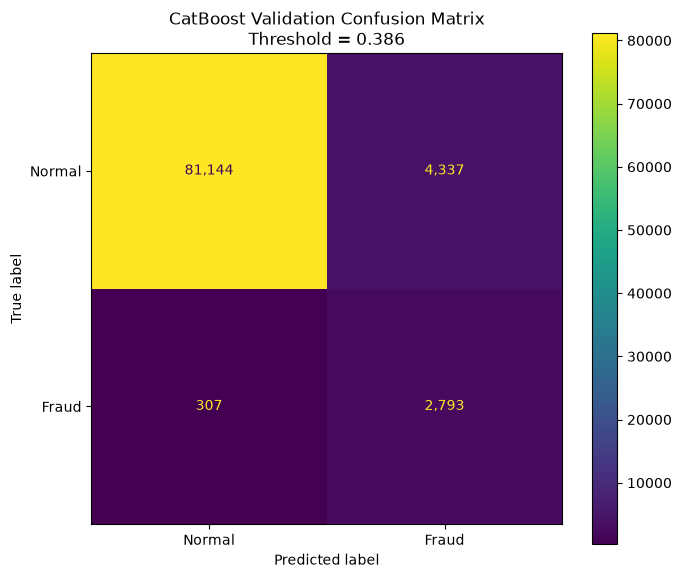

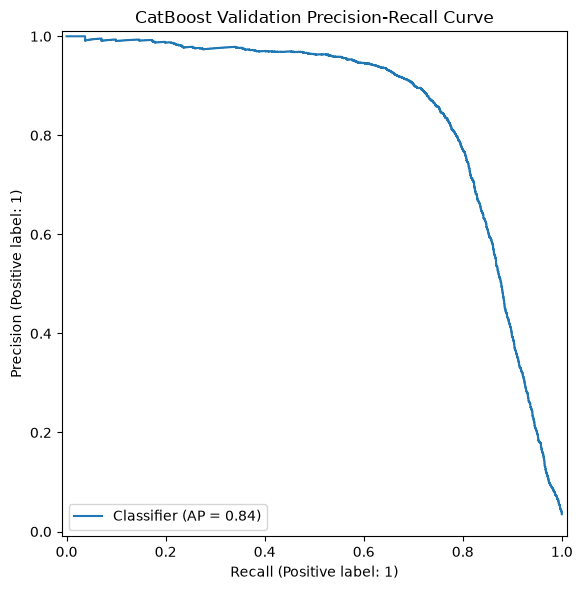

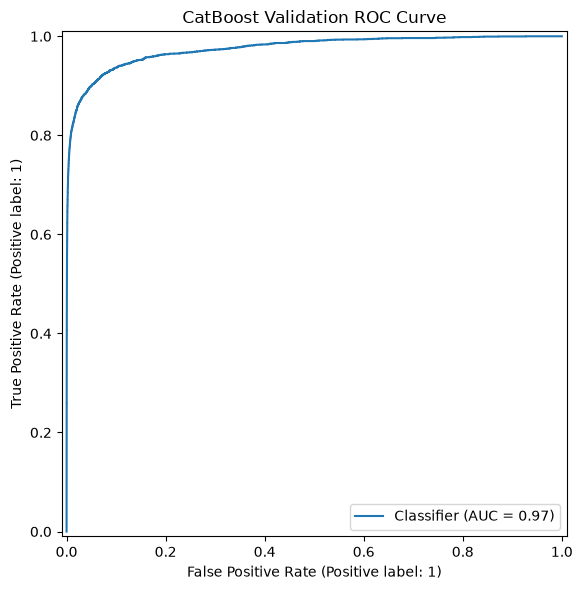

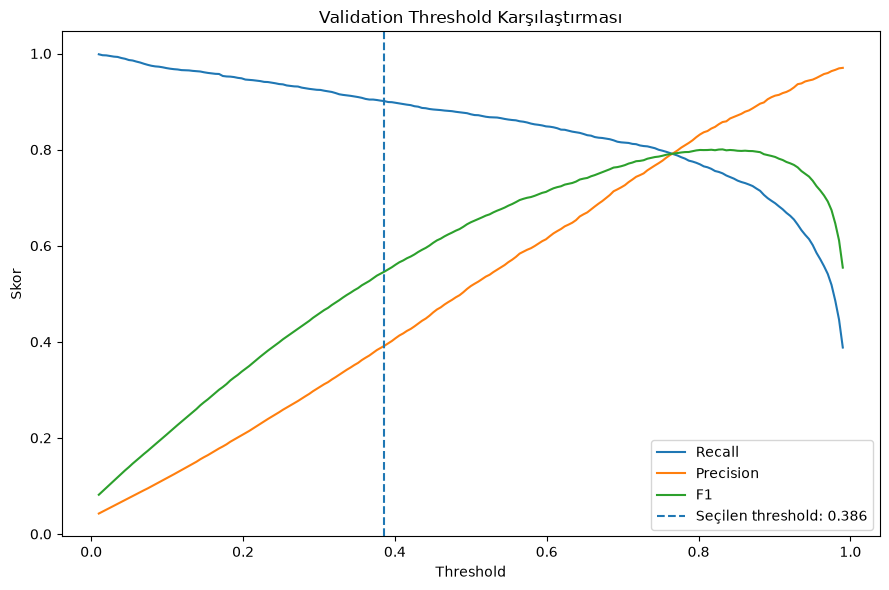

Görseller kaydedildi:
 - C:\Users\pc\Desktop\YZTA-Bootcamp-2026\outputs\figures\catboost_validation_confusion_matrix.png
 - C:\Users\pc\Desktop\YZTA-Bootcamp-2026\outputs\figures\catboost_validation_precision_recall_curve.png
 - C:\Users\pc\Desktop\YZTA-Bootcamp-2026\outputs\figures\catboost_validation_roc_curve.png
 - C:\Users\pc\Desktop\YZTA-Bootcamp-2026\outputs\figures\catboost_threshold_comparison.png


In [18]:

# ============================================================
# 18) VALIDATION GÖRSELLERİ
# ============================================================

validation_predictions = (
    validation_probabilities >= selected_threshold
).astype(np.int8)

# Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_val,
    validation_predictions,
    labels=[0, 1],
    display_labels=["Normal", "Fraud"],
    values_format=",d",
    ax=ax,
)
ax.set_title(
    f"CatBoost Validation Confusion Matrix\n"
    f"Threshold = {selected_threshold:.3f}"
)
fig.tight_layout()
validation_cm_path = (
    FIGURES_DIR
    / "catboost_validation_confusion_matrix.png"
)
fig.savefig(validation_cm_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close(fig)

# Precision-Recall Curve
fig, ax = plt.subplots(figsize=(7, 6))
PrecisionRecallDisplay.from_predictions(
    y_val,
    validation_probabilities,
    ax=ax,
)
ax.set_title("CatBoost Validation Precision-Recall Curve")
fig.tight_layout()
validation_pr_path = (
    FIGURES_DIR
    / "catboost_validation_precision_recall_curve.png"
)
fig.savefig(validation_pr_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close(fig)

# ROC Curve
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(
    y_val,
    validation_probabilities,
    ax=ax,
)
ax.set_title("CatBoost Validation ROC Curve")
fig.tight_layout()
validation_roc_path = (
    FIGURES_DIR
    / "catboost_validation_roc_curve.png"
)
fig.savefig(validation_roc_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close(fig)

# Threshold - Recall / Precision / F1
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(
    threshold_results["threshold"],
    threshold_results["recall"],
    label="Recall",
)
ax.plot(
    threshold_results["threshold"],
    threshold_results["precision"],
    label="Precision",
)
ax.plot(
    threshold_results["threshold"],
    threshold_results["f1"],
    label="F1",
)
ax.axvline(
    selected_threshold,
    linestyle="--",
    label=f"Seçilen threshold: {selected_threshold:.3f}",
)
ax.set_xlabel("Threshold")
ax.set_ylabel("Skor")
ax.set_title("Validation Threshold Karşılaştırması")
ax.legend()
fig.tight_layout()
threshold_figure_path = (
    FIGURES_DIR
    / "catboost_threshold_comparison.png"
)
fig.savefig(threshold_figure_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close(fig)

print("Görseller kaydedildi:")
print(" -", validation_cm_path)
print(" -", validation_pr_path)
print(" -", validation_roc_path)
print(" -", threshold_figure_path)



## Final test değerlendirmesi

Seçilen model ve validation threshold artık değiştirilmeden test setine uygulanır.

Bu sonuç, CatBoost ağır model adayının final yerel test sonucudur.


In [19]:

# ============================================================
# 19) TEST SETİNDE FİNAL DEĞERLENDİRME
# ============================================================

with StepTimer("Test tahminleri"):
    test_started = time.perf_counter()
    test_probabilities = model.predict_proba(test_pool)[:, 1]
    test_inference_seconds = time.perf_counter() - test_started

test_predictions = (
    test_probabilities >= selected_threshold
).astype(np.int8)

test_metrics = calculate_metrics(
    y_test,
    test_probabilities,
    threshold=selected_threshold,
)

test_metrics.update({
    "model": "CatBoostClassifier",
    "device": used_device,
    "training_seconds": float(training_seconds),
    "test_inference_seconds": float(test_inference_seconds),
    "test_rows": int(len(y_test)),
    "inference_seconds_per_10k": float(
        test_inference_seconds / len(y_test) * 10_000
    ),
    "best_iteration": int(model.get_best_iteration()),
    "selection_reason": selection_reason,
})

print(pd.Series(test_metrics, name="CatBoost Test"))



BAŞLADI: Test tahminleri
TAMAMLANDI: Test tahminleri — 0.3 sn
[Test tahminleri] RAM kullanımı: 2.59 GB
threshold                                                             0.386162
precision                                                             0.402244
recall                                                                0.902227
f1                                                                    0.556418
roc_auc                                                               0.975725
pr_auc                                                                0.854984
tn                                                                       81327
fp                                                                        4155
fn                                                                         303
tp                                                                        2796
positive_prediction_rate                                              0.078471
model                      

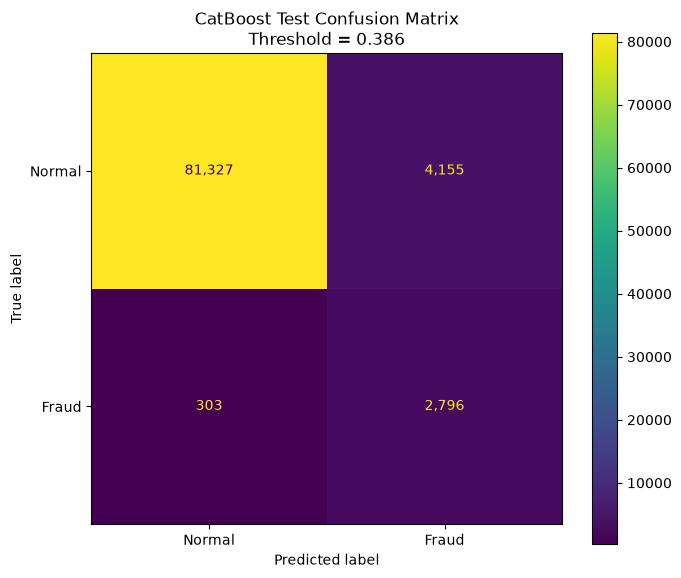

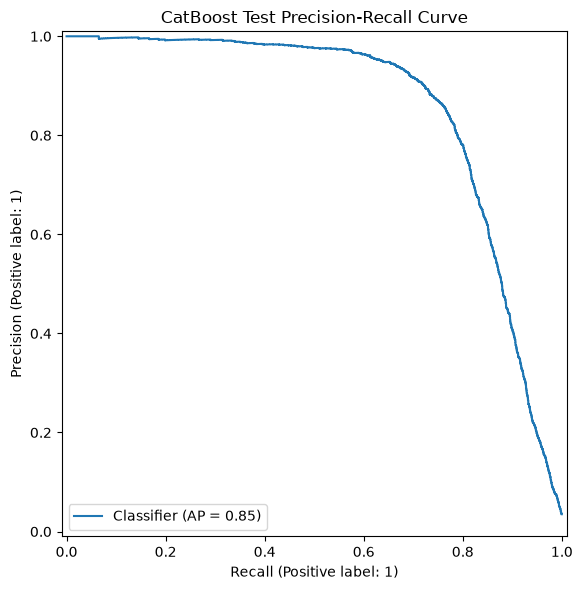

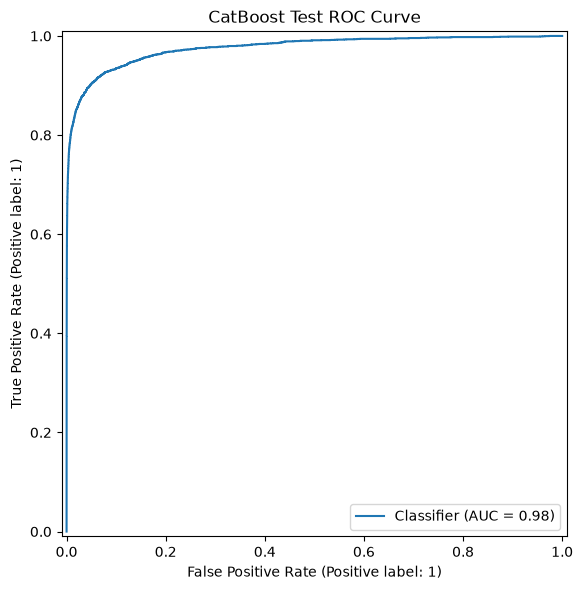

Test görselleri kaydedildi.


In [20]:

# ============================================================
# 20) TEST GÖRSELLERİ
# ============================================================

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    labels=[0, 1],
    display_labels=["Normal", "Fraud"],
    values_format=",d",
    ax=ax,
)
ax.set_title(
    f"CatBoost Test Confusion Matrix\n"
    f"Threshold = {selected_threshold:.3f}"
)
fig.tight_layout()
test_cm_path = (
    FIGURES_DIR
    / "catboost_test_confusion_matrix.png"
)
fig.savefig(test_cm_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(7, 6))
PrecisionRecallDisplay.from_predictions(
    y_test,
    test_probabilities,
    ax=ax,
)
ax.set_title("CatBoost Test Precision-Recall Curve")
fig.tight_layout()
test_pr_path = (
    FIGURES_DIR
    / "catboost_test_precision_recall_curve.png"
)
fig.savefig(test_pr_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(
    y_test,
    test_probabilities,
    ax=ax,
)
ax.set_title("CatBoost Test ROC Curve")
fig.tight_layout()
test_roc_path = (
    FIGURES_DIR
    / "catboost_test_roc_curve.png"
)
fig.savefig(test_roc_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close(fig)

print("Test görselleri kaydedildi.")



BAŞLADI: Feature importance hesaplama
TAMAMLANDI: Feature importance hesaplama — 13.6 sn
[Feature importance hesaplama] RAM kullanımı: 2.61 GB


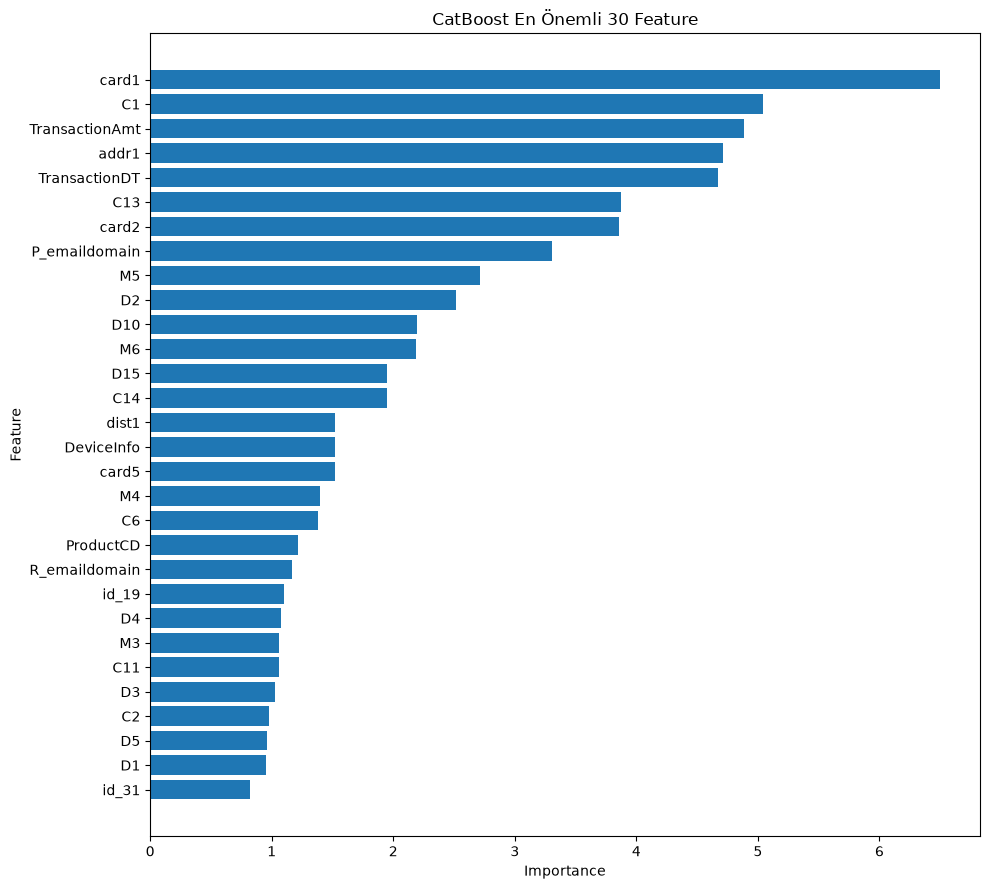

,feature,importance
0,card1,6.502225
1,C1,5.044175
2,TransactionAmt,4.885173
3,addr1,4.710649
4,TransactionDT,4.673956
5,C13,3.877233
6,card2,3.856551
7,P_emaildomain,3.306333
8,M5,2.712707
9,D2,2.515471


Feature importance CSV: C:\Users\pc\Desktop\YZTA-Bootcamp-2026\outputs\metrics\catboost_feature_importance.csv
Feature importance görseli: C:\Users\pc\Desktop\YZTA-Bootcamp-2026\outputs\figures\catboost_feature_importance_top30.png


In [21]:

# ============================================================
# 21) FEATURE IMPORTANCE
# ============================================================

with StepTimer("Feature importance hesaplama"):
    importance_values = model.get_feature_importance(
        train_pool,
        type="FeatureImportance",
    )

feature_importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": importance_values,
}).sort_values(
    "importance",
    ascending=False,
).reset_index(drop=True)

importance_csv_path = (
    METRICS_DIR
    / "catboost_feature_importance.csv"
)
feature_importance.to_csv(
    importance_csv_path,
    index=False,
)

top_n = min(30, len(feature_importance))
top_importance = (
    feature_importance
    .head(top_n)
    .sort_values("importance")
)

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(
    top_importance["feature"],
    top_importance["importance"],
)
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
ax.set_title(f"CatBoost En Önemli {top_n} Feature")
fig.tight_layout()

importance_figure_path = (
    FIGURES_DIR
    / "catboost_feature_importance_top30.png"
)
fig.savefig(
    importance_figure_path,
    dpi=160,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

display(feature_importance.head(30))

print("Feature importance CSV:", importance_csv_path)
print("Feature importance görseli:", importance_figure_path)



## Model ve sonuçların kaydedilmesi

Kaydedilen model yalnızca CatBoost model dosyası değildir. Ayrıca şu bilgiler JSON metadata dosyasına yazılır:

- Kullanılan feature listesi
- Kategorik feature listesi
- Kaldırılan kolonlar
- Seçilen threshold
- Model parametreleri
- Test metrikleri
- Kullanılan cihaz
- En iyi iterasyon

Böylece model daha sonra pipeline veya dashboard içinde güvenli biçimde kullanılabilir.


In [22]:

# ============================================================
# 22) MODELİ, METRİKLERİ VE TAHMİNLERİ KAYDET
# ============================================================

model_path = MODEL_DIR / "catboost_heavy_model.cbm"
model.save_model(model_path)

metrics_path = METRICS_DIR / "catboost_test_metrics.json"

with open(metrics_path, "w", encoding="utf-8") as file:
    json.dump(
        test_metrics,
        file,
        ensure_ascii=False,
        indent=2,
    )

metadata = {
    "model_name": "catboost_heavy_model",
    "model_path": str(model_path),
    "target_column": TARGET_COL,
    "id_column": ID_COL,
    "feature_columns": feature_columns,
    "categorical_columns": categorical_cols,
    "numeric_columns": numeric_cols,
    "high_missing_threshold": HIGH_MISSING_THRESHOLD,
    "dropped_high_missing_columns": high_missing_cols,
    "dropped_constant_columns": constant_cols,
    "selected_threshold": selected_threshold,
    "selection_reason": selection_reason,
    "device": used_device,
    "best_iteration": int(model.get_best_iteration()),
    "base_model_params": base_model_params,
    "test_metrics": test_metrics,
}

metadata_path = MODEL_DIR / "catboost_heavy_model_metadata.json"

with open(metadata_path, "w", encoding="utf-8") as file:
    json.dump(
        metadata,
        file,
        ensure_ascii=False,
        indent=2,
    )

prediction_frame = pd.DataFrame({
    "TransactionID": id_test,
    "y_true": y_test,
    "fraud_probability": test_probabilities,
    "prediction": test_predictions,
})

predictions_path = (
    PREDICTIONS_DIR
    / "catboost_test_predictions.csv"
)
prediction_frame.to_csv(
    predictions_path,
    index=False,
)

split_path = METRICS_DIR / "catboost_split_indices.npz"
np.savez_compressed(
    split_path,
    train_idx=train_idx,
    val_idx=val_idx,
    test_idx=test_idx,
)

print("Kaydedilen dosyalar:")
print(" - Model:", model_path)
print(" - Metadata:", metadata_path)
print(" - Test metrikleri:", metrics_path)
print(" - Test tahminleri:", predictions_path)
print(" - Split indeksleri:", split_path)


Kaydedilen dosyalar:
 - Model: C:\Users\pc\Desktop\YZTA-Bootcamp-2026\models\heavy\catboost_heavy_model.cbm
 - Metadata: C:\Users\pc\Desktop\YZTA-Bootcamp-2026\models\heavy\catboost_heavy_model_metadata.json
 - Test metrikleri: C:\Users\pc\Desktop\YZTA-Bootcamp-2026\outputs\metrics\catboost_test_metrics.json
 - Test tahminleri: C:\Users\pc\Desktop\YZTA-Bootcamp-2026\outputs\predictions\catboost_test_predictions.csv
 - Split indeksleri: C:\Users\pc\Desktop\YZTA-Bootcamp-2026\outputs\metrics\catboost_split_indices.npz


In [23]:

# ============================================================
# 23) TAMAMLANMA ÖZETİ
# ============================================================

summary = pd.DataFrame([
    {
        "Model": "CatBoost",
        "Rol": "Ağır model adayı",
        "Cihaz": used_device,
        "Threshold": selected_threshold,
        "Precision": test_metrics["precision"],
        "Recall": test_metrics["recall"],
        "F1": test_metrics["f1"],
        "ROC-AUC": test_metrics["roc_auc"],
        "PR-AUC": test_metrics["pr_auc"],
        "Training dakika": training_seconds / 60,
        "10K inference sn": test_metrics[
            "inference_seconds_per_10k"
        ],
    }
])

display(summary)

print("\nCATBOOST NOTEBOOK'U BAŞARIYLA TAMAMLANDI.")
print(
    "Sonraki adım: Bu sonucu diğer ağır model adaylarıyla "
    "aynı split üzerinde karşılaştırmak."
)
print(
    "Hafif-ağır pipeline, hafif ve ağır model adayları "
    "ayrı ayrı değerlendirildikten sonra kurulmalıdır."
)


,Model,Rol,Cihaz,Threshold,Precision,Recall,F1,ROC-AUC,PR-AUC,Training dakika,10K inference sn
0,CatBoost,Ağır model adayı,GPU,0.386162,0.402244,0.902227,0.556418,0.975725,0.854984,3.013796,0.031846



CATBOOST NOTEBOOK'U BAŞARIYLA TAMAMLANDI.
Sonraki adım: Bu sonucu diğer ağır model adaylarıyla aynı split üzerinde karşılaştırmak.
Hafif-ağır pipeline, hafif ve ağır model adayları ayrı ayrı değerlendirildikten sonra kurulmalıdır.



# Üretilen dosyalar

Notebook tamamlandığında repo içinde yaklaşık olarak şu çıktılar oluşur:

```text
models/heavy/
├── catboost_heavy_model.cbm
└── catboost_heavy_model_metadata.json

outputs/metrics/
├── catboost_data_report.json
├── catboost_validation_threshold_results.csv
├── catboost_test_metrics.json
├── catboost_feature_importance.csv
└── catboost_split_indices.npz

outputs/predictions/
└── catboost_test_predictions.csv

outputs/figures/
├── catboost_validation_confusion_matrix.png
├── catboost_validation_precision_recall_curve.png
├── catboost_validation_roc_curve.png
├── catboost_threshold_comparison.png
├── catboost_test_confusion_matrix.png
├── catboost_test_precision_recall_curve.png
├── catboost_test_roc_curve.png
└── catboost_feature_importance_top30.png
```

## Önemli yorum

Bu notebook CatBoost'u **ağır model adayı** olarak eğitir. CatBoost'un kesin ağır model olduğuna henüz karar verilmez.

Sonuç daha sonra LightGBM, XGBoost veya diğer ağır model adaylarıyla aynı split üzerinde karşılaştırılmalıdır. İki aşamalı mimari de ancak bu karşılaştırmalar tamamlandıktan sonra test edilmelidir.
